In [1]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import matplotlib.cm as cm
import seaborn as sb
from os import mkdir
import os
import warnings
import squarify
import matplotlib as mpl
import seaborn as sns

sc.set_figure_params(dpi=60, 
                     dpi_save=300, 
                     color_map= 'viridis_r',transparent=True,
                     frameon=True, vector_friendly=False, fontsize=14,
                     format='pdf')

plt.rcParams['figure.figsize']=(10,10) #rescale figures
plt.rcParams['grid.alpha']=0
sc.settings.verbosity = 3
#sc.logging.print_header()

In [2]:
adata= sc.read ('../cell_annotation_brain_NBs_1_Drosophila_and_Tribolium_label_transfer.h5ad')
#Core genes from all pathways downloaded from flybase
df = pd.read_csv("1_ALL_genes_with_pathways.csv")

In [3]:
remove_labels = [
    "plasmatocytes/embryonic hemocytes/macrophages",
    "Mesodermal/muscle progenitors",
    "PCGs"
]

adata = adata[~adata.obs["X_scVI_harmony_predicted"].isin(remove_labels)].copy()

In [4]:
adata

AnnData object with n_obs × n_vars = 27341 × 4766
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'dataset', 'manually_cell_types', '_scvi_batch', '_scvi_labels', 'X_scVI_harmony_predicted', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'X_scVI_harmony_predicted_colors', 'X_scVI_harmony_predicted_sizes', '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'dendrogram_X_scVI_harmony_predicted', 'hvg', 'leiden', 'leiden_0.5', 'leiden_0.5_colors', 'leid

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


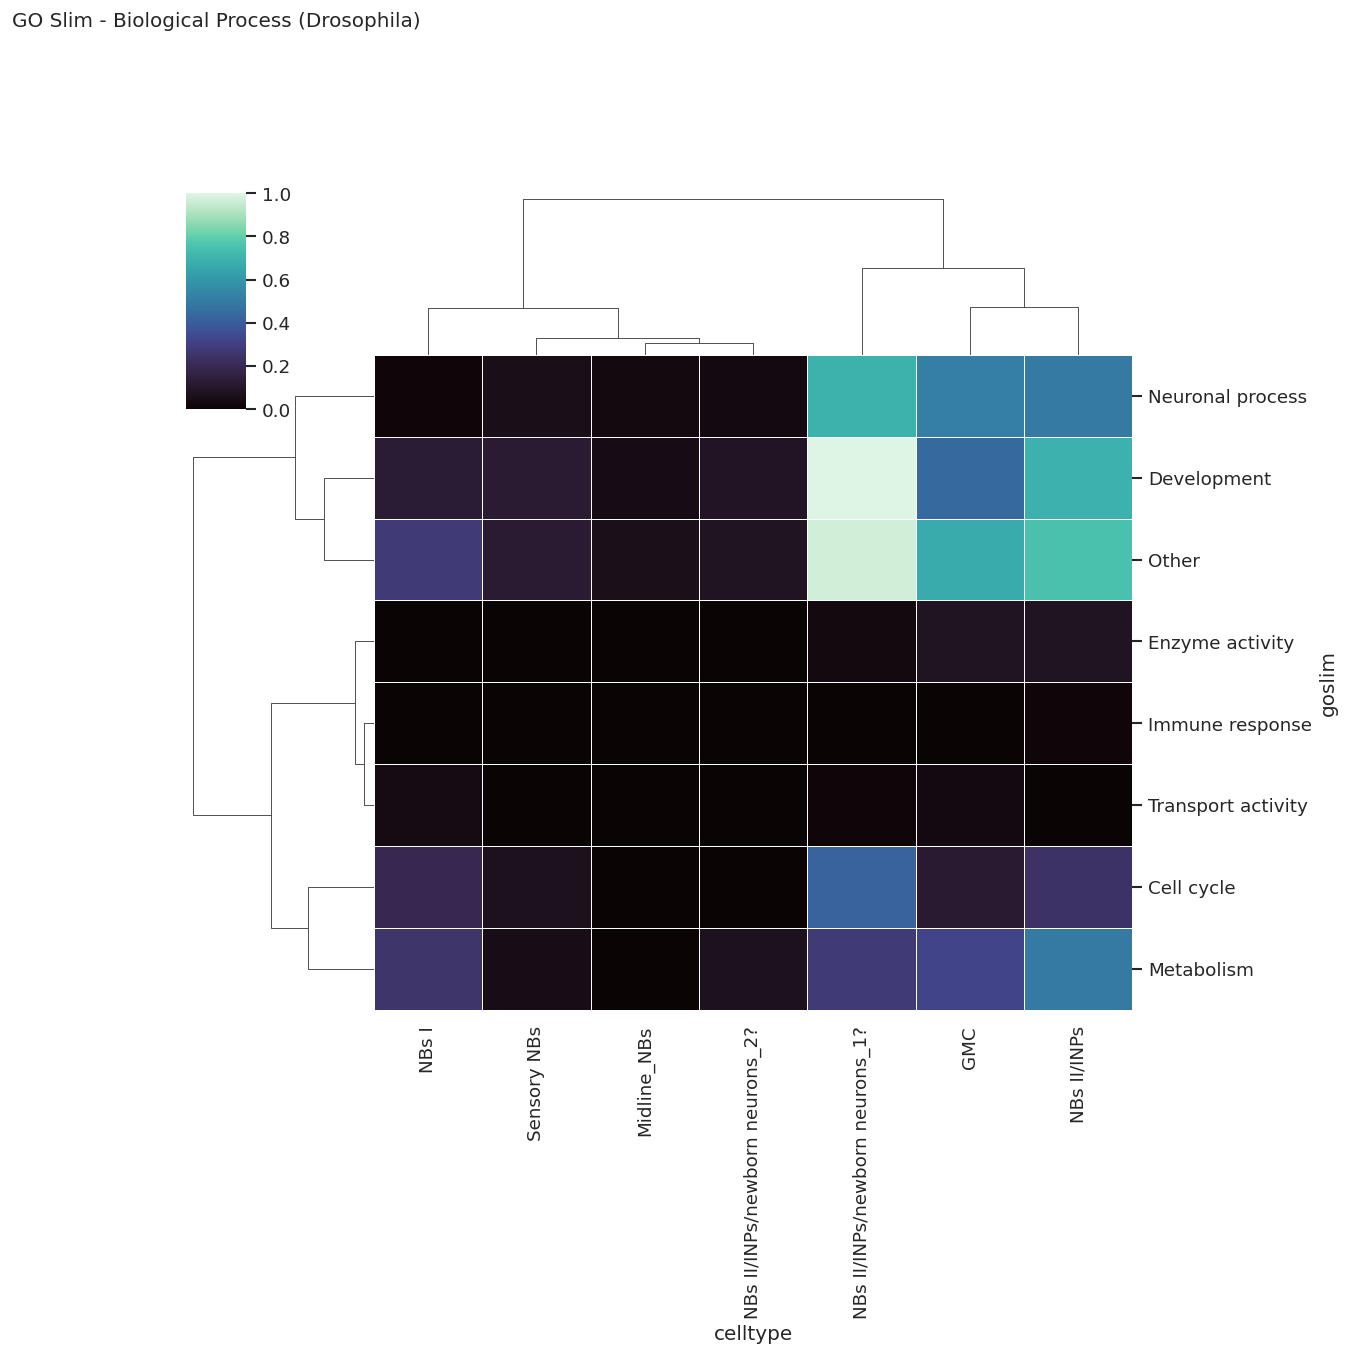

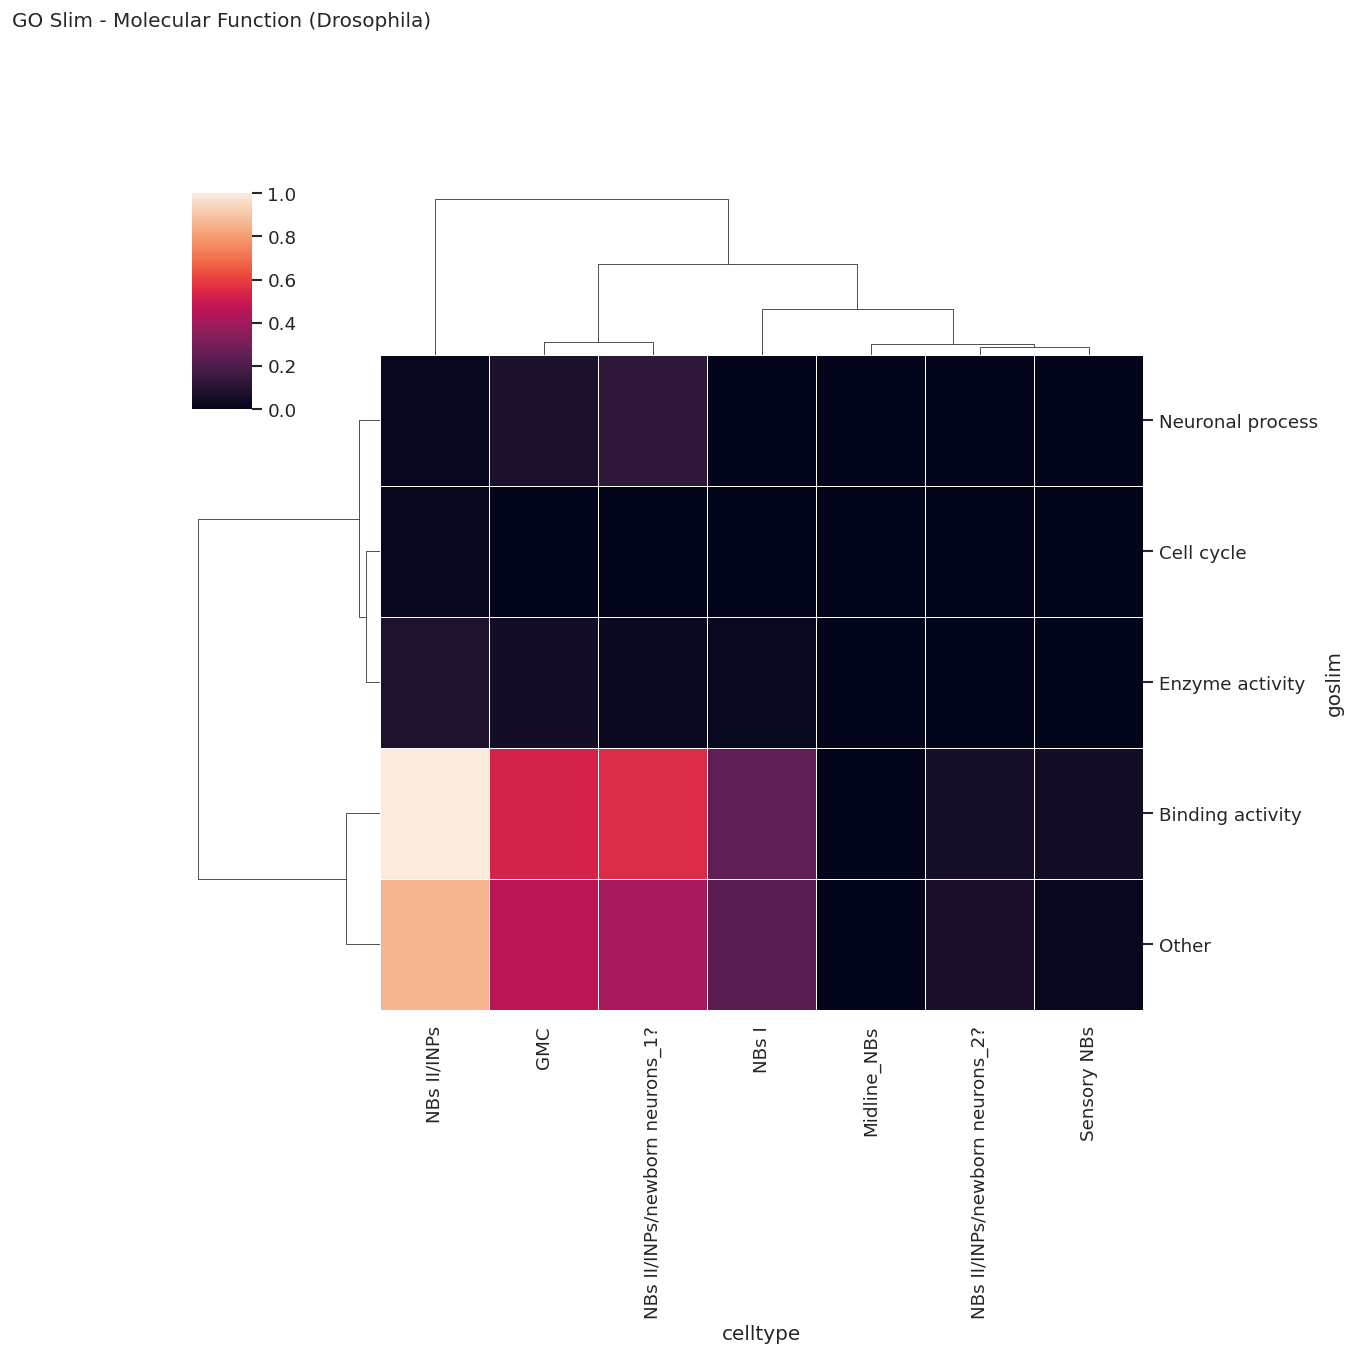

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from gprofiler import GProfiler


groupby = "X_scVI_harmony_predicted"

sc.tl.rank_genes_groups(
    adata,
    groupby=groupby,
    method="wilcoxon",
    n_genes=500
)

markers = {}

for ct in adata.obs[groupby].unique():
    df = sc.get.rank_genes_groups_df(adata, group=ct)
    genes = df[df["pvals_adj"] < 0.05]["names"].tolist()
    markers[ct] = genes

gp = GProfiler(return_dataframe=True)

go_results = {"BP": {}, "MF": {}}

for ct, genes in markers.items():
    if len(genes) < 10:
        continue

    for source in ["GO:BP", "GO:MF"]:
        res = gp.profile(
            organism="dmelanogaster",
            query=genes,
            sources=[source]
        )
        go_results[source.split(":")[1]][ct] = res


def goslim_map(df):
    df = df.copy()

    def classify(term):
        t = term.lower()

        if any(x in t for x in ["neuro", "synap", "axon", "signal"]):
            return "Neuronal process"
        if any(x in t for x in ["immune", "defense", "antimicro"]):
            return "Immune response"
        if any(x in t for x in ["metabolic", "catabolic", "biosynth"]):
            return "Metabolism"
        if any(x in t for x in ["cell cycle", "mitotic", "division"]):
            return "Cell cycle"
        if any(x in t for x in ["development", "differentiation", "morphogen"]):
            return "Development"
        if any(x in t for x in ["binding"]):
            return "Binding activity"
        if any(x in t for x in ["kinase", "phosphat"]):
            return "Enzyme activity"
        if any(x in t for x in ["channel", "transporter"]):
            return "Transport activity"

        return "Other"

    df["goslim"] = df["description"].apply(classify)
    return df


def build_matrix(go_dict):
    dfs = []

    for ct, df in go_dict.items():
        if df is None or len(df) == 0:
            continue

        df = df[df["p_value"] < 0.05].copy()
        df = goslim_map(df)

        df["celltype"] = ct
        dfs.append(df)

    all_df = pd.concat(dfs)

    mat = all_df.pivot_table(
        index="goslim",
        columns="celltype",
        values="p_value",
        aggfunc="min"
    )

    mat = -np.log10(mat)

    # normalize 0–1
    mat = (mat - mat.min().min()) / (mat.max().max() - mat.min().min())

    return mat.fillna(0)


bp_mat = build_matrix(go_results["BP"])
mf_mat = build_matrix(go_results["MF"])


sns.set(style="white")

g1 = sns.clustermap(
    bp_mat,
    cmap="mako",
    linewidths=0.3,
    figsize=(10, 10),
    vmin=0, vmax=1,
    metric="euclidean",
    method="average"
)

plt.title("GO Slim - Biological Process (Drosophila)", pad=100)
plt.savefig("GO_BP_slim_clustermap.pdf")
plt.show()

g2 = sns.clustermap(
    mf_mat,
    cmap="rocket",
    linewidths=0.3,
    figsize=(10, 10),
    vmin=0, vmax=1,
    metric="euclidean",
    method="average"
)

plt.title("GO Slim - Molecular Function (Drosophila)", pad=100)

plt.setp(g2.ax_heatmap.get_xticklabels(), rotation=90)

plt.savefig("GO_MF_slim_clustermap.pdf")
plt.show()

bp_mat.to_csv("GO_BP_slim_matrix.csv")
mf_mat.to_csv("GO_MF_slim_matrix.csv")

In [6]:
def to_proportions(mat):
    df = mat.copy()
    
    # normalize each column (cell type) to sum to 1
    df = df.div(df.sum(axis=0), axis=1)
    
    return df

bp_prop = to_proportions(bp_mat)
mf_prop = to_proportions(mf_mat)

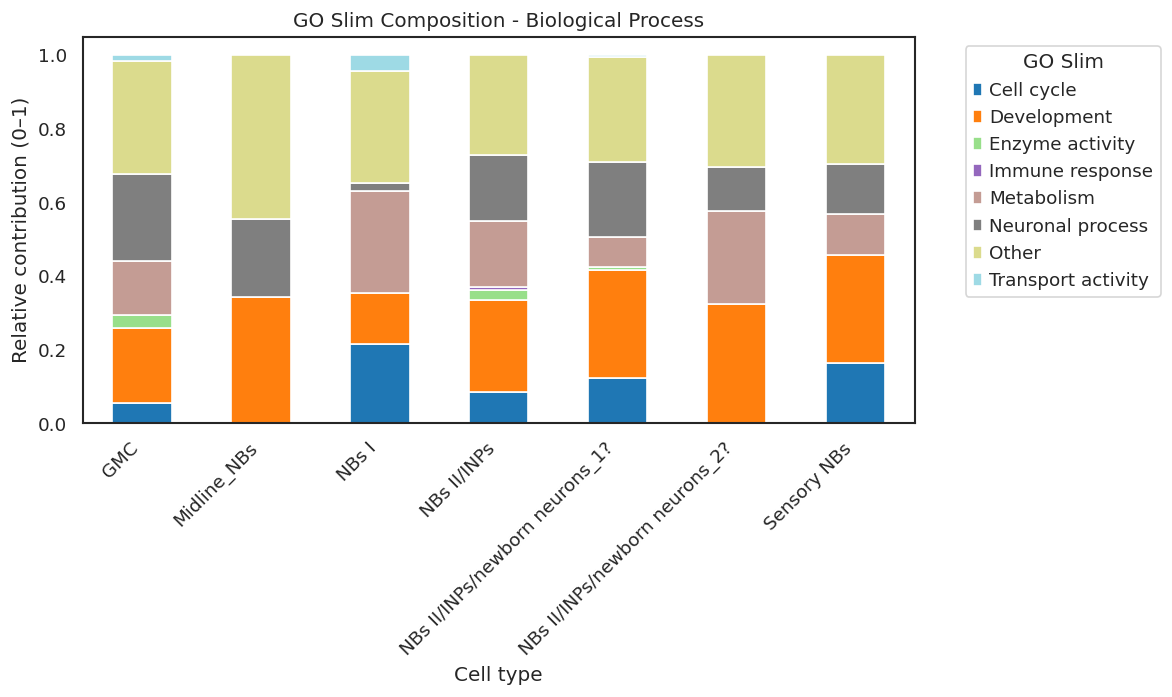

In [7]:
bp_prop.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)

plt.ylabel("Relative contribution (0–1)")
plt.xlabel("Cell type")
plt.title("GO Slim Composition - Biological Process")

plt.xticks(rotation=45, ha="right")
plt.legend(
    title="GO Slim",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("GO_BP_stacked_barplot.pdf",)
plt.show()

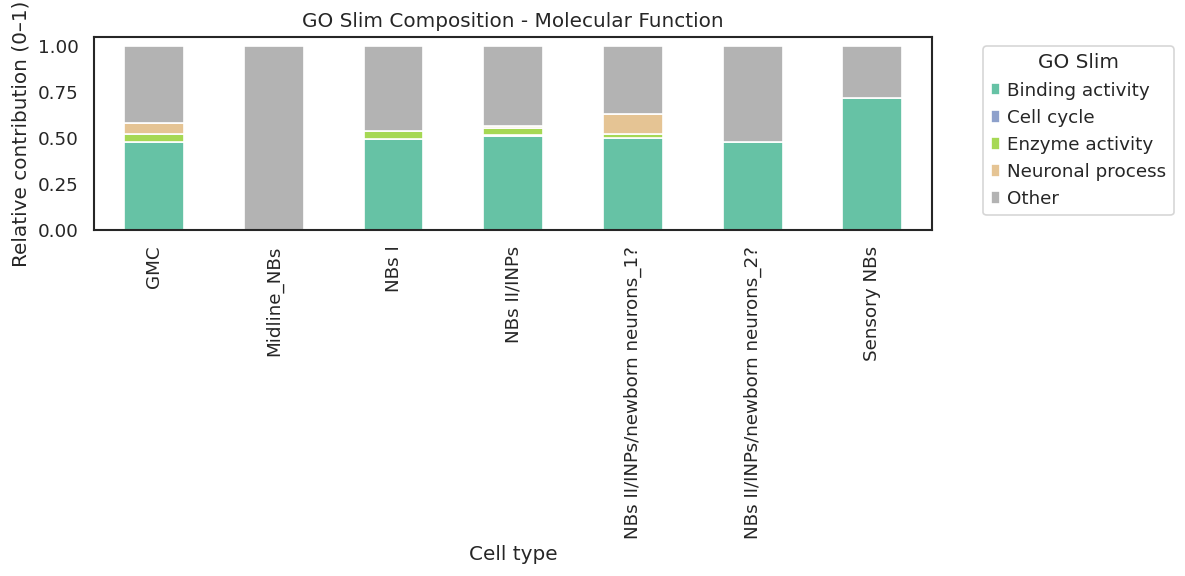

In [8]:
mf_prop.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="Set2"
)

plt.ylabel("Relative contribution (0–1)")
plt.xlabel("Cell type")
plt.title("GO Slim Composition - Molecular Function")

plt.xticks(rotation=90)

plt.legend(
    title="GO Slim",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("GO_MF_stacked_barplot.pdf")
plt.show()